In [4]:
import numpy as np
import pandas as pd
#import geopandas as gpd
import matplotlib.pyplot as plt
#import seaborn as sns

In [6]:
df = pd.read_csv('../../data/Meters/Parking_Meters.csv')
df.describe()
df.head()

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3460: DtypeWarning: Columns (28,30) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,OBJECTID,PARKING_SPACE_ID,POST_ID,MS_PAY_STATION_ID,MS_SPACE_NUM,SENSOR_FLAG,ON_OFFSTREET_TYPE,OSP_ID,JURISDICTION,PM_DISTRICT_ID,...,NFC_KEY,SPT_CODE,COLLECTION_ROUTE_DESC,COLLECTION_SUBROUTE_DESC,shape,Neighborhoods,SF Find Neighborhoods,Current Police Districts,Current Supervisor Districts,Analysis Neighborhoods
0,33521,132627,818-01520,-,0,Y,ON,0,PORT,2,...,NaN,NaN,NaN,NaN,POINT (-122.389114 37.784286),31,31,1,10,8
1,33670,131615,831-04060,-,0,Y,ON,0,PORT,2,...,NaN,NaN,NaN,NaN,POINT (-122.388504 37.789272),30,30,1,10,8
2,33707,131649,561-02041,561-02040,1,N,ON,0,SFMTA,1,...,NaN,NaN,NaN,NaN,POINT (-122.39328 37.790424),108,108,1,10,8
3,33848,132817,561-03160,-,0,N,ON,0,SFMTA,2,...,3SP5,NaN,NaN,NaN,POINT (-122.39142 37.788933),30,30,1,10,8
4,33895,132860,658-01430,-,0,E,ON,0,SFMTA,1,...,4RJ4,NaN,Folsom St: Unit-800 1st:,Spear Unit-300,POINT (-122.39334 37.792076),108,108,1,10,8


In [15]:
# POST_ID is the unique id to indicate the meter 
# Remove all the invalid POST_ID
df_invalid = df.groupby('POST_ID').count()['METER_TYPE']
l_invalid = df_invalid[df_invalid != 1].index.values
df_post_valid = df[~ df['POST_ID'].isin(l_invalid)].reset_index(drop=1)

In [16]:
columns = ['POST_ID', 'MS_PAY_STATION_ID', 'MS_SPACE_NUM', 'ON_OFFSTREET_TYPE', 'OSP_ID', 
           'PM_DISTRICT_ID', 'BLOCKFACE_ID', 'METER_TYPE', 'OLD_RATE_AREA', 'STREET_ID', 
           'STREET_NAME', 'STREET_NUM', 'ORIENTATION', 'LONGITUDE', 'LATITUDE', 'COLLECTION_ROUTE_DESC', 
           'COLLECTION_SUBROUTE_DESC', 'Neighborhoods', 'Analysis Neighborhoods']

In [17]:
# Select all general metered parking
# and only keep the important features
df_general = df_post_valid[df_post_valid['CAP_COLOR'] == 'Grey'].reset_index(drop=1)
df_general = df_general[columns]

In [18]:
df_general.to_csv('../../data/Meters/Parking_Meters_new.csv')

In [19]:
df_general

,POST_ID,MS_PAY_STATION_ID,MS_SPACE_NUM,ON_OFFSTREET_TYPE,OSP_ID,PM_DISTRICT_ID,BLOCKFACE_ID,METER_TYPE,OLD_RATE_AREA,STREET_ID,STREET_NAME,STREET_NUM,ORIENTATION,LONGITUDE,LATITUDE,COLLECTION_ROUTE_DESC,COLLECTION_SUBROUTE_DESC,Neighborhoods,Analysis Neighborhoods
0,818-01520,-,0,ON,0,2,818012,SS,-,818,BRANNAN ST,152,315,-122.389130,37.784290,NaN,NaN,31,8
1,561-03160,-,0,ON,0,2,561032,SS,-,561,MAIN ST,316,225,-122.391429,37.788938,NaN,NaN,30,8
2,418-02270,-,0,ON,0,2,418021,SS,Area 1,418,FOLSOM ST,227,135,-122.392502,37.788747,NaN,NaN,30,8
3,386-02170,-,0,ON,0,1,386021,SS,-,386,DRUMM ST,217,270,-122.396997,37.796047,NaN,NaN,108,8
4,328-02330,-,0,ON,0,1,328021,SS,Area 1,328,BEALE ST,233,45,-122.393219,37.789203,NaN,NaN,108,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21877,321-03180,-,0,ON,0,40,321032,SS,Area 3,321,BALBOA ST,318,0,-122.462599,37.777366,Balboa St: 200 - 500,Balboa 200- 500,5,11
21878,118-04020,909-00001,2,OFF,909,21,118041,MS,Area 3,118,18TH AVE,421,270,-122.477336,37.779947,Geary St at 18th St: Lot,Geary at 18th Lot,5,29
21879,365-08040,-,0,ON,0,30,365082,SS,Area 3,365,CORTLAND AVE,804,180,-122.414358,37.738843,Cortland Ave: 300 - 900,Cortland,83,2
21880,108-03240,903-00002,20,OFF,903,9,108032,MS,Area 3,108,08TH AVE,324,90,-122.466159,37.782294,Clement St at 8th Ave: Lot,8th Ave Clement Lot,5,11


In [20]:
# Find the SS meters and transform to number for better aggregation
df_general.loc[df_general['METER_TYPE']=='SS','SS_SPACE_NUM'] = 1

In [21]:
# Aggregate by BLOCKFACE_ID
# (log,lat) and space num
df_block = df_general.groupby('BLOCKFACE_ID').mean()[['LONGITUDE','LATITUDE']]
df_block['MS_SPACE_NUM'] = df_general.groupby('BLOCKFACE_ID').sum()['MS_SPACE_NUM']
df_block['SS_SPACE_NUM'] = df_general.groupby('BLOCKFACE_ID').sum()['SS_SPACE_NUM']
df_block['SPACE_NUM'] = df_block['MS_SPACE_NUM'] + df_block['SS_SPACE_NUM']
df_block['OLD_RATE_AREA'] = df_general.groupby('BLOCKFACE_ID').apply(lambda x:x['OLD_RATE_AREA'].values[0]) 

In [22]:
# area_rate = dict(zip(df_block['OLD_RATE_AREA'].unique(),range(len(df_block['OLD_RATE_AREA'].unique()))))
df_block['OLD_RATE_AREA_id'] = df_block['OLD_RATE_AREA'].apply(lambda x:area_rate[x])

In [26]:
df_block.to_csv('../../data/Meters/Meter_block.csv')

In [9]:
gdf_sf = gpd.read_file("../../data/Meters/Zone/geo_export_eb015d13-a647-4b4b-acd4-1f4921a6b1fe.shp")

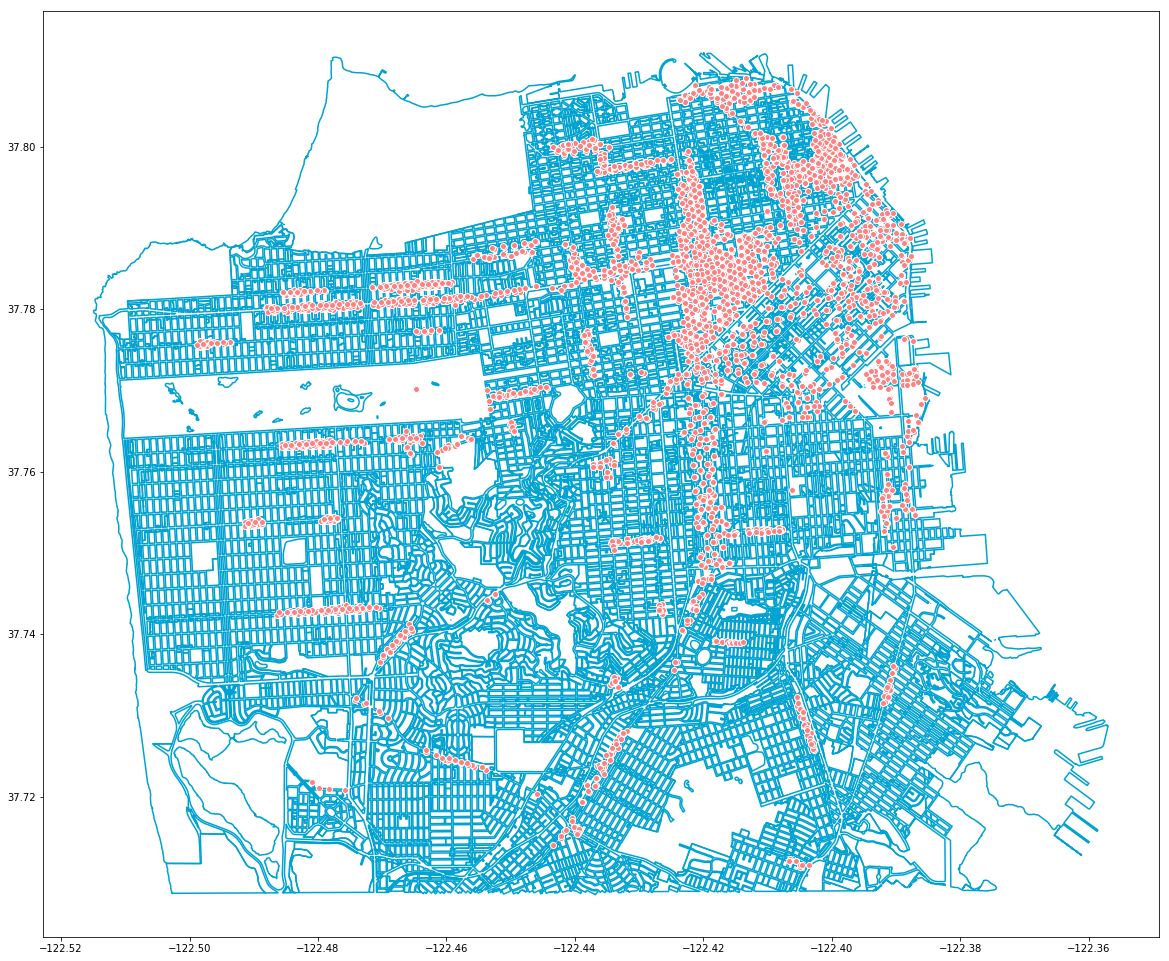

In [10]:
fig, ax = plt.subplots(figsize=(20, 20))
gdf_sf.boundary.plot(ax=ax,color='#00A2D1',zorder=0)
plt.scatter(df_block['LONGITUDE'],df_block['LATITUDE'],c='#FF8080',edgecolor='white',zorder=10)